In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("/home/void/Documents/codes/monadvsim/prepared_data/ethiopia_occurrence/merged_observations.csv")

In [4]:
df.describe()

,year,latitude,longitude
count,72.000000,72.000000,72.000000
mean,2019.819444,8.085841,41.221551
std,1.825688,1.815264,2.244814
min,2016.000000,4.126372,35.080234
25%,2018.000000,6.775139,39.388407
50%,2020.000000,7.753527,41.238367
75%,2021.000000,9.402825,43.099123
max,2023.000000,12.269964,44.682746


In [22]:
labels = df['year']
labels = list(set(labels))
labels

[2016, 2018, 2019, 2020, 2021, 2022, 2023]

In [23]:
values = {}
for year in labels:
    val_row = {
        "Literature": len(df[(df['year'] == year) & (df['source'] != 'GBIF')]),
        "Online DB": len(df[(df['year'] == year) & (df['source'] == 'GBIF')])
    }
    values[year] = val_row
print(values)

{2016: {'Literature': 1, 'Online DB': 3}, 2018: {'Literature': 9, 'Online DB': 10}, 2019: {'Literature': 3, 'Online DB': 0}, 2020: {'Literature': 22, 'Online DB': 0}, 2021: {'Literature': 10, 'Online DB': 0}, 2022: {'Literature': 8, 'Online DB': 0}, 2023: {'Literature': 6, 'Online DB': 0}}


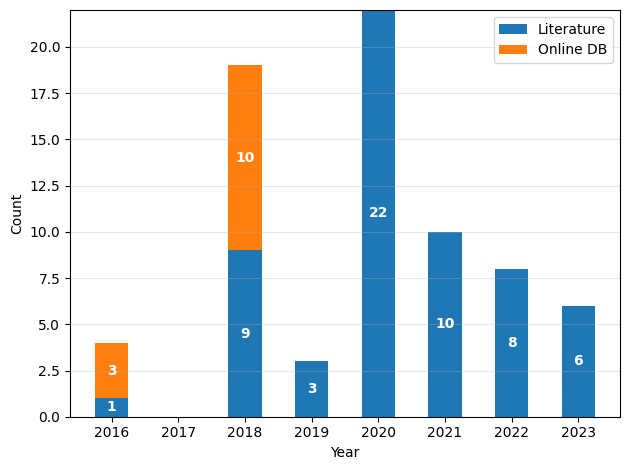

In [28]:
fig, ax = plt.subplots()
bottom = np.zeros(len(labels))
width = 0.5
source_types = list(values[labels[0]].keys())

# Plot each source type as a stack
for source in source_types:
    # Build the values array for this source in the correct order
    source_values = []
    for year in labels:
        source_values.append(values[year][source])
    
    source_values = np.array(source_values)
    
    # Plot the bars
    ax.bar(labels, source_values, width, label=source, bottom=bottom)
    
    # Add value labels
    for i, (year, value) in enumerate(zip(labels, source_values)):
        if value > 0:
            ax.text(year, bottom[i] + value/2, str(int(value)), 
                   ha='center', va='center', color='white', fontweight='bold')
    
    # Update bottom for the next stack
    bottom += source_values

# ax.set_title("Number of observations per year and sources.")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs/occurrence_data_distribution.png")
plt.show()